# Data characterisation — methods section

Three parts:

1. **Spectral analysis across all seven damage categories** — how the optical signal
   changes as severity increases, and whether Planet imagery already shows July damage
   on footprints that are still labelled intact in May.

2. **Spatial clustering and data-leakage risk** — KNN-based local damage rate as a
   spatial smoother, then a direct comparison of random vs latitude-quantile splits to
   quantify how much cross-split contamination each approach produces.

3. **Systematic split comparison** — structural differences between train / stack / val /
   test under the binary labelling rule (UNOSAT classes 1–3 = damaged, 4 and 11 = intact).

**Seven categories** (ordered by expected severity, excluding class 6 and NaN):

| Key | UNOSAT | Assessment | Binary label |
|---|---|---|---|
| `c11` | No visible damage | May 2024 | 0 intact |
| `c4`  | Possibly damaged   | May 2024 | 0 intact (class 4 excluded) |
| `c3`  | Moderately damaged | May 2024 | 1 damaged |
| `c2`  | Severely damaged   | May 2024 | 1 damaged |
| `c1`  | Destroyed          | May 2024 | 1 damaged |
| `new_part` | Newly partly damaged (class 3–4) | Jul 2025 only | 0 intact in May |
| `new_full` | Newly fully destroyed (class 1–2) | Jul 2025 only | 0 intact in May |

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
!pip install -q rasterio geopandas scikit-learn scipy

In [ ]:
from scipy.stats import gaussian_kde


In [ ]:
import os, glob
import numpy as np
import pandas as pd
import geopandas as gpd
from pathlib import Path
from scipy.spatial import cKDTree
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from matplotlib.patches import Patch

PROJECT_DIR = Path('/content/drive/MyDrive/Colab Notebooks/War_Damage')

JUL_GDB = str(PROJECT_DIR / 'UNOSAT_GazaStrip_CDA_08July2025.gdb')

BANDS = ['B','G','R','NIR']
PRE   = [0,1,2,3]
POST  = [4,5,6,7]

# load NPZ
files = sorted(glob.glob(str(PROJECT_DIR / 'datasets' / 'Gaza_*.npz')))
assert files, f'No .npz in {PROJECT_DIR}/datasets/'
z = np.load(files[-1], allow_pickle=False)
X        = z['X'].astype('float32')
y_binary = z['y'].astype(int)

# load parquet
parquet_path = files[-1].replace('.npz', '.parquet')
table = gpd.read_parquet(parquet_path).reset_index(drop=True)

# ensure lon/lat and area exist
if 'lon' not in table.columns or 'lat' not in table.columns:
    centroids = table.geometry.centroid
    table['lon'] = centroids.x
    table['lat'] = centroids.y
if 'area' not in table.columns:
    table['area'] = table.to_crs('EPSG:32636').geometry.area

print(f'Loaded {os.path.basename(files[-1])}')
print(f'X: {X.shape}  y: {y_binary.shape}  table: {len(table):,} rows')
print(f'Prevalence (1–3 rule): {100*y_binary.mean():.1f}%')

/tmp/ipykernel_3688/1516954608.py:32: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  centroids = table.geometry.centroid


Loaded Gaza_20240503_9a2734d7a2.npz
X: (228725, 14, 32, 32)  y: (228725,)  table: 228,725 rows
Prevalence (1–3 rule): 57.5%


## 0 · Assign seven-category labels

Join the UNOSAT July GDB (which carries both assessment dates) to each footprint
via a 100 m nearest-neighbour spatial join. Footprints whose nearest UNOSAT point
is farther than 100 m are treated as unmatched and excluded from category plots.

In [ ]:
print('Joining UNOSAT 5-way labels …')

# table geometry is already in some CRS — use UTM for distance-based join
if table.crs is None or table.crs.to_epsg() != 32636:
    table_utm = table.set_crs('EPSG:4326', allow_override=True).to_crs('EPSG:32636')
else:
    table_utm = table.copy()

jul = gpd.read_file(JUL_GDB, layer='Damage_Sites_GazaStrip_20250708',
                    columns=['geometry','Main_Damage_Site_Class_7',
                             'Main_Damage_Site_Class_13'])
jul_utm = jul.to_crs('EPSG:4326').to_crs('EPSG:32636')

joined = gpd.sjoin_nearest(
    table_utm[['geometry']].assign(idx=np.arange(len(table))),
    jul_utm[['geometry','Main_Damage_Site_Class_7','Main_Damage_Site_Class_13']],
    how='left', max_distance=100
).drop_duplicates('idx').set_index('idx').sort_index()

FULLY={1,2}; PARTLY={3,4}
def grp(c):
    if pd.isna(c): return 'none'
    c=int(c); return 'fully' if c in FULLY else ('partly' if c in PARTLY else 'none')

cls_may = joined['Main_Damage_Site_Class_7']
cls_jul = joined['Main_Damage_Site_Class_13']
grp_may = cls_may.map(grp).fillna('none')
grp_jul = cls_jul.map(grp).fillna('none')

def assign7(i):
    cm = cls_may.get(i, np.nan); gm = grp_may.get(i, 'none')
    cj = cls_jul.get(i, np.nan); gj = grp_jul.get(i, 'none')
    if pd.isna(cm):   # no May annotation
        if gj == 'fully':  return 'new_full'
        if gj == 'partly': return 'new_part'
        return None
    c = int(cm)
    if c == 11: return 'c11'
    if c == 4:  return 'c4'
    if c == 3:  return 'c3'
    if c == 2:  return 'c2'
    if c == 1:  return 'c1'
    return None   # class 6 or unexpected

cat7 = np.array([assign7(i) for i in range(len(X))], dtype=object)

CAT_META = {
    'c11':      dict(label='11 — No visible damage',    color='#6C757D', binary=0),
    'c4':       dict(label='4 — Possibly damaged',      color='#ADB5BD', binary=0),
    'c3':       dict(label='3 — Moderately damaged',    color='#FFC107', binary=1),
    'c2':       dict(label='2 — Severely damaged',      color='#E67E22', binary=1),
    'c1':       dict(label='1 — Destroyed',             color='#E74C3C', binary=1),
    'new_part': dict(label='Jul — newly partly damaged',color='#27AE60', binary=0),
    'new_full': dict(label='Jul — newly fully destroyed',color='#2980B9',binary=0),
}
ORDER = ['c11','c4','c3','c2','c1','new_part','new_full']

print('Category distribution:')
for k in ORDER:
    m = CAT_META[k]; n = (cat7==k).sum()
    print(f'  {m["label"]:36s} {n:>8,}  binary={m["binary"]}')
print(f'  {"unmatched / class 6":36s} {(cat7==None).sum():>8,}')

Joining UNOSAT 5-way labels …
Category distribution:
  11 — No visible damage                  4,626  binary=0
  4 — Possibly damaged                   38,843  binary=0
  3 — Moderately damaged                 60,245  binary=1
  2 — Severely damaged                   18,337  binary=1
  1 — Destroyed                          35,456  binary=1
  Jul — newly partly damaged             19,200  binary=0
  Jul — newly fully destroyed            42,704  binary=0
  unmatched / class 6                     9,314


## A · Spectral analysis across seven categories

### A1 — Spectral signatures (mean reflectance by band)

Figures folder: /content/drive/MyDrive/Colab Notebooks/War_Damage/figures


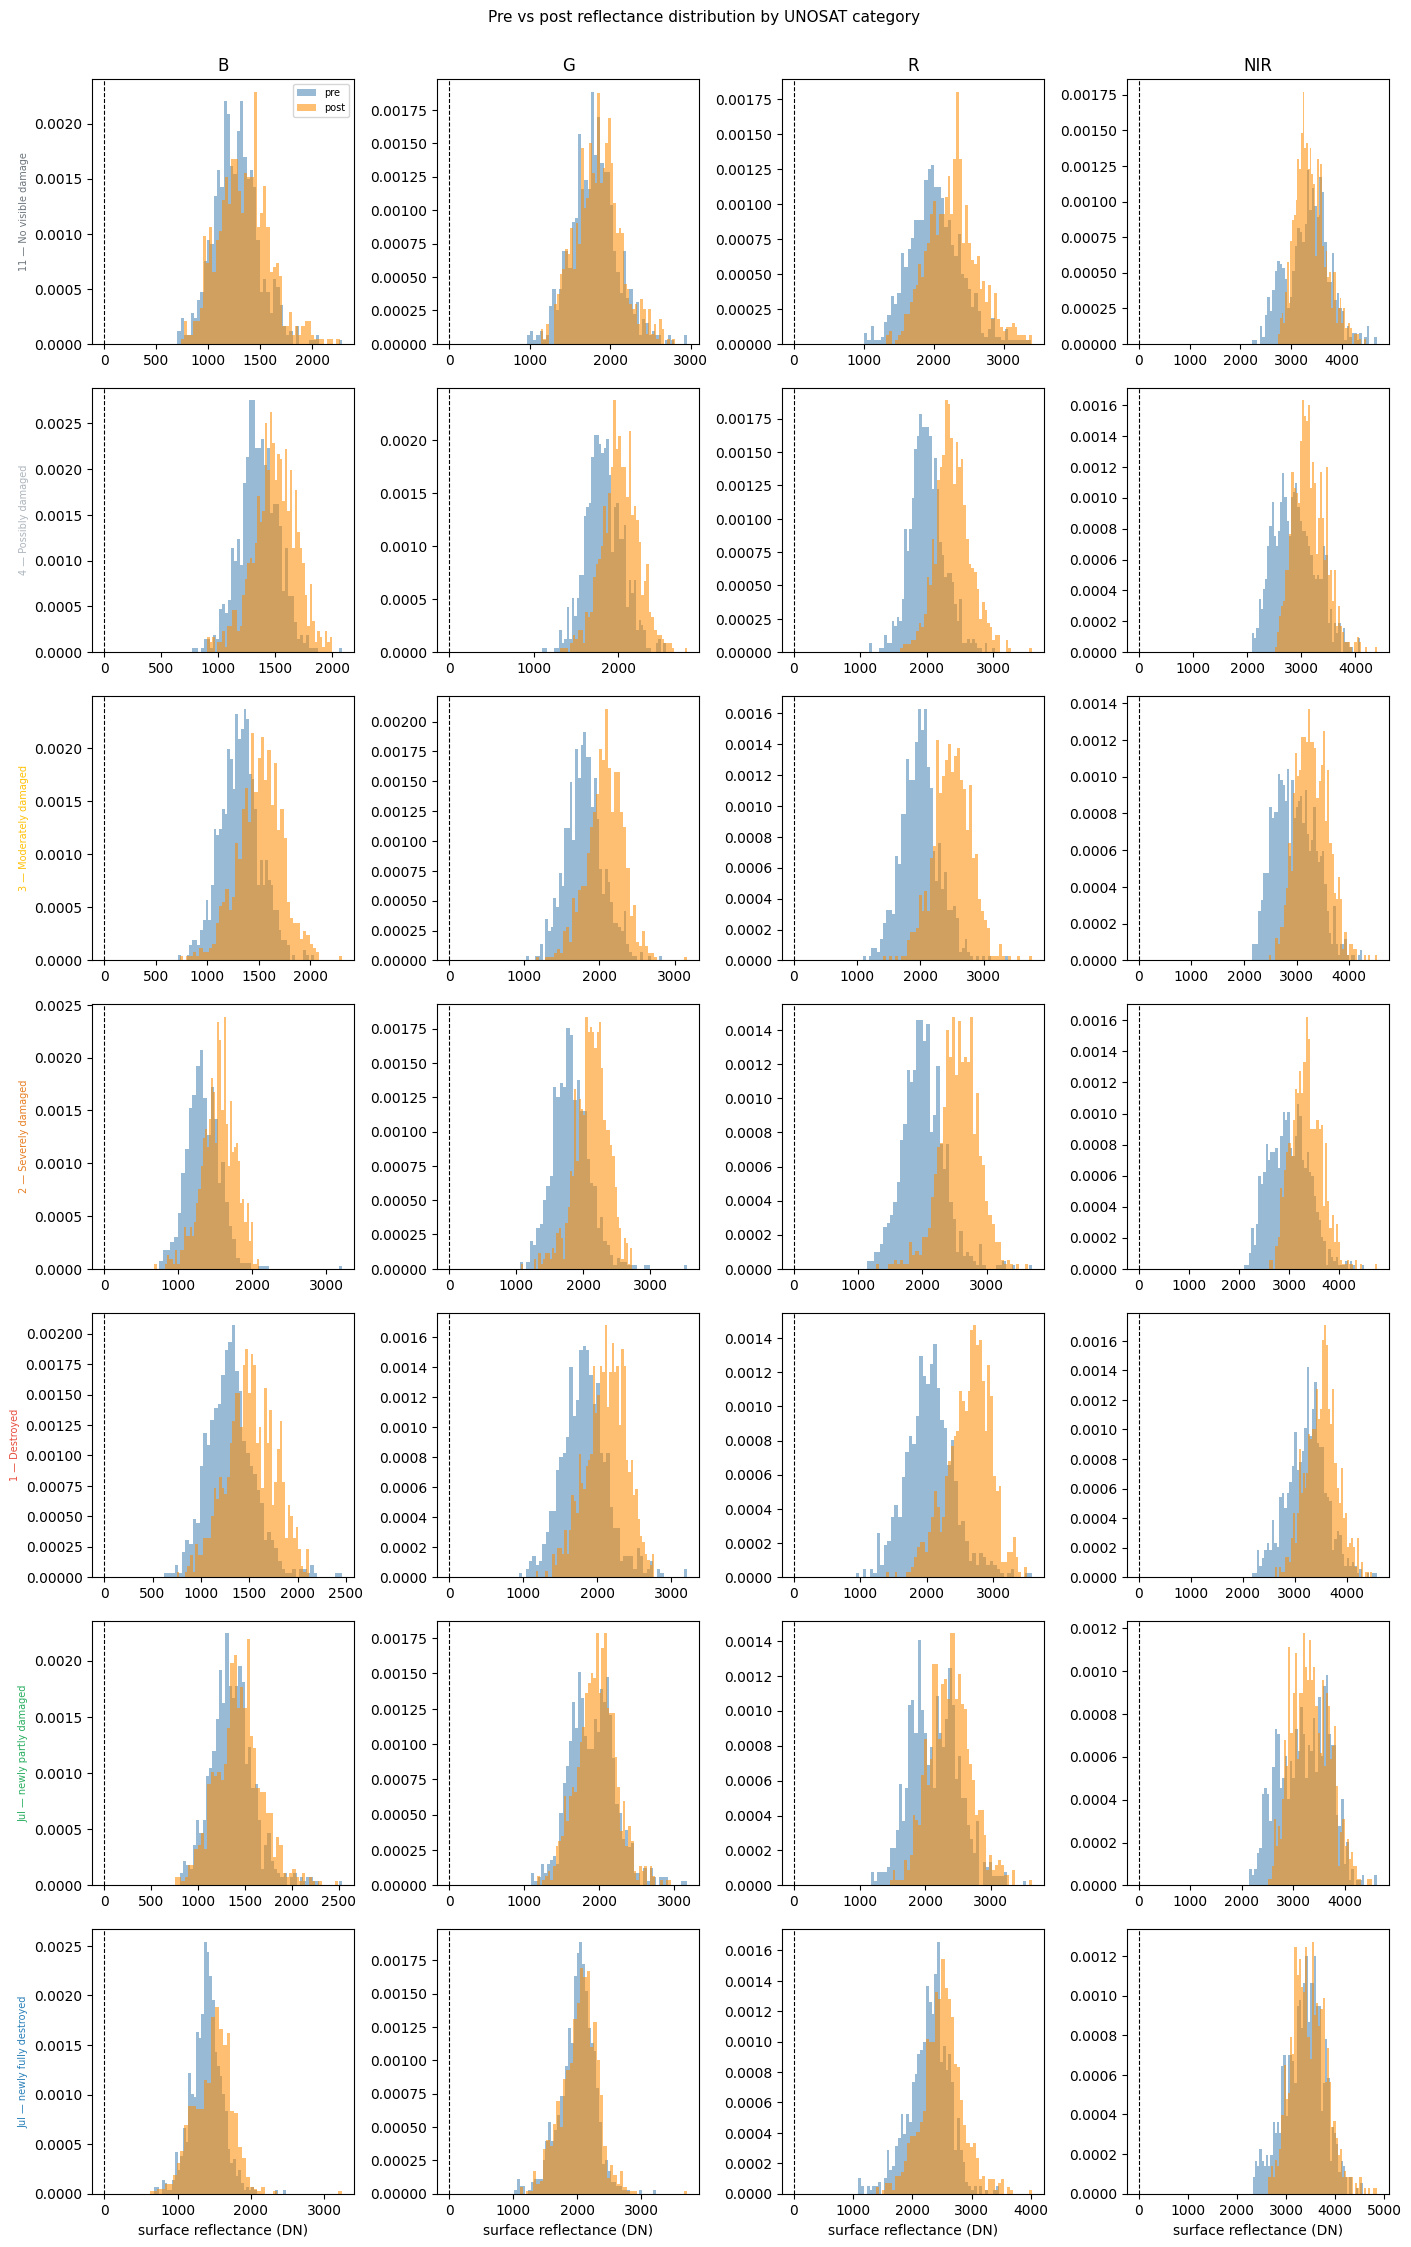

In [ ]:
rng = np.random.default_rng(0)
N_SAMP = 800   # per category for speed

FIGURES_DIR = PROJECT_DIR / 'figures'
FIGURES_DIR.mkdir(parents=True, exist_ok=True)
print('Figures folder:', FIGURES_DIR)

means_pre  = {k: [] for k in ORDER}
means_post = {k: [] for k in ORDER}
ndvi_delta = {k: [] for k in ORDER}
change     = {k: {b: [] for b in BANDS} for k in ORDER}

for k in ORDER:
    idx = np.where(cat7 == k)[0]
    if len(idx) == 0: continue
    sel = rng.choice(idx, min(N_SAMP, len(idx)), replace=False)
    patches = X[sel]                                  # (n, 8, 32, 32)
    mp = patches[:, PRE].mean(axis=(2,3))             # (n, 4)
    mq = patches[:, POST].mean(axis=(2,3))
    means_pre[k]  = mp
    means_post[k] = mq
    for j,b in enumerate(BANDS):
        change[k][b] = (mq[:,j] - mp[:,j]).tolist()
    pre_ndvi  = (mp[:,3]-mp[:,2]) / np.maximum(mp[:,3]+mp[:,2], 1e-6)
    post_ndvi = (mq[:,3]-mq[:,2]) / np.maximum(mq[:,3]+mq[:,2], 1e-6)
    ndvi_delta[k] = (post_ndvi - pre_ndvi).tolist()

# ── plot: mean pre vs post spectral signatures ──────────────────────────────

fig, axes = plt.subplots(7, 4, figsize=(14, 3.2 * 7))

for row_i, k in enumerate(ORDER):
    cat_idx = np.where(cat7 == k)[0]
    if len(cat_idx) == 0:
        continue
    sel = rng.choice(cat_idx, min(N_SAMP, len(cat_idx)), replace=False)
    m = X[sel].mean(axis=(2, 3))    # (n, 8) — patch-mean per band

    for j, (ax, band) in enumerate(zip(axes[row_i], BANDS)):
        ax.hist(m[:, j],     bins=50, density=True, alpha=.55,
                color='steelblue', label='pre')
        ax.hist(m[:, j + 4], bins=50, density=True, alpha=.55,
                color='darkorange', label='post')
        ax.axvline(0, color='black', linewidth=.8, linestyle='--')
        if row_i == 0:
            ax.set_title(f'{band}')
        if row_i == 6:
            ax.set_xlabel('surface reflectance (DN)')
        if j == 0:
            ax.set_ylabel(CAT_META[k]['label'], fontsize=7,
                          color=CAT_META[k]['color'])
        if row_i == 0 and j == 0:
            ax.legend(fontsize=7)

plt.suptitle('Pre vs post reflectance distribution by UNOSAT category',
             y=1.001, fontsize=11)
plt.tight_layout()
plt.savefig(str(FIGURES_DIR / 'eda_pre_post_distributions.png'),
            dpi=150, bbox_inches='tight')
plt.show()

band,B,G,NIR,R
category,,,,
11 — No visible damage,71.7,49.6,126.7,245.0
4 — Possibly damaged,143.9,182.0,251.9,377.9
3 — Moderately damaged,189.7,266.8,308.1,496.2
2 — Severely damaged,201.8,293.1,344.9,543.2
1 — Destroyed,221.1,319.0,336.5,617.3
Jul — newly partly damaged,72.1,59.4,124.8,233.7
Jul — newly fully destroyed,87.3,51.3,106.5,234.0


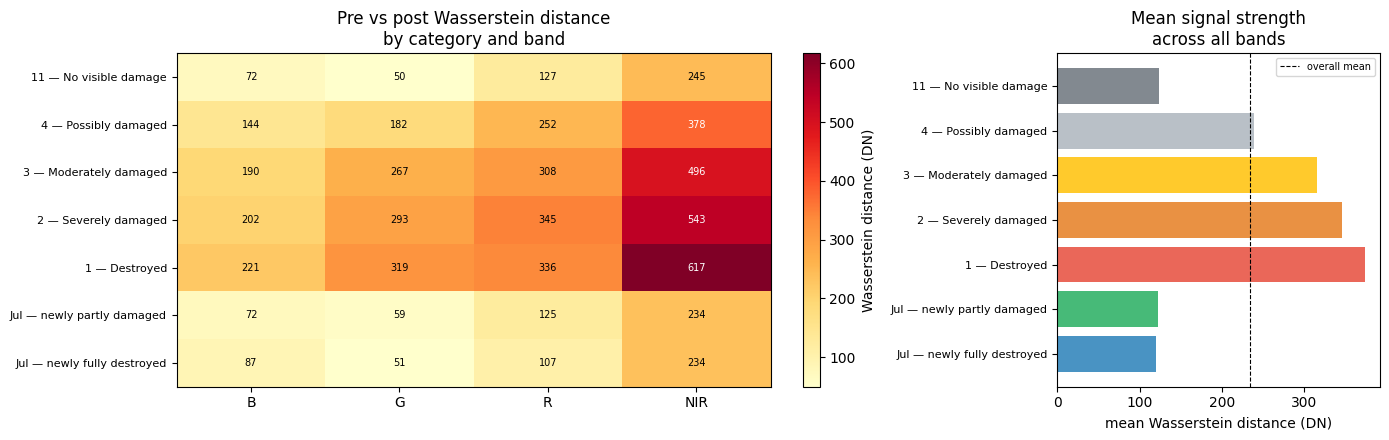

In [ ]:
from scipy.stats import wasserstein_distance

# ── compute Wasserstein distance (pre vs post) for every category × band ──────
records = []
for k in ORDER:
    cat_idx = np.where(cat7 == k)[0]
    if len(cat_idx) == 0:
        continue
    sel = rng.choice(cat_idx, min(N_SAMP, len(cat_idx)), replace=False)
    m = X[sel].mean(axis=(2, 3))    # (n, 8)
    for j, band in enumerate(BANDS):
        wd = wasserstein_distance(m[:, j], m[:, j + 4])
        records.append({'category': CAT_META[k]['label'],
                        'band': band, 'wasserstein': wd,
                        'key': k})

wd_df = pd.DataFrame(records)
display(wd_df.pivot(index='category', columns='band', values='wasserstein')
             .reindex([CAT_META[k]['label'] for k in ORDER])
             .round(1))

# ── heatmap ───────────────────────────────────────────────────────────────────
pivot = wd_df.pivot(index='key', columns='band',
                    values='wasserstein').reindex(ORDER)

fig, axes = plt.subplots(1, 2, figsize=(14, 4.5),
                         gridspec_kw={'width_ratios': [2, 1]})

# left: heatmap
import matplotlib.cm as mcm
im = axes[0].imshow(pivot.values, cmap='YlOrRd', aspect='auto')
axes[0].set_xticks(range(4)); axes[0].set_xticklabels(BANDS)
axes[0].set_yticks(range(len(ORDER)))
axes[0].set_yticklabels([CAT_META[k]['label'] for k in ORDER], fontsize=8)
for i in range(len(ORDER)):
    for j in range(4):
        axes[0].text(j, i, f'{pivot.values[i,j]:.0f}',
                     ha='center', va='center', fontsize=7,
                     color='white' if pivot.values[i,j] > pivot.values.max()*0.6
                     else 'black')
plt.colorbar(im, ax=axes[0], fraction=.03, label='Wasserstein distance (DN)')
axes[0].set_title('Pre vs post Wasserstein distance\nby category and band')

# right: mean across bands per category (severity gradient)
mean_wd = pivot.mean(axis=1)
colors  = [CAT_META[k]['color'] for k in ORDER]
axes[1].barh(range(len(ORDER)), mean_wd.values[::-1],
             color=colors[::-1], alpha=.85)
axes[1].set_yticks(range(len(ORDER)))
axes[1].set_yticklabels([CAT_META[k]['label'] for k in ORDER[::-1]], fontsize=8)
axes[1].set_xlabel('mean Wasserstein distance (DN)')
axes[1].set_title('Mean signal strength\nacross all bands')
axes[1].axvline(mean_wd.values.mean(), color='k', ls='--',
                lw=.8, label='overall mean')
axes[1].legend(fontsize=7)

plt.tight_layout()
plt.savefig(str(FIGURES_DIR / 'eda_wasserstein.png'),
            dpi=150, bbox_inches='tight')
plt.show()

c11 (no damage)  : 4,626 patches
c1  (destroyed)  : 35,456 patches
No July-problem patches included — both pools are May-only assessments.


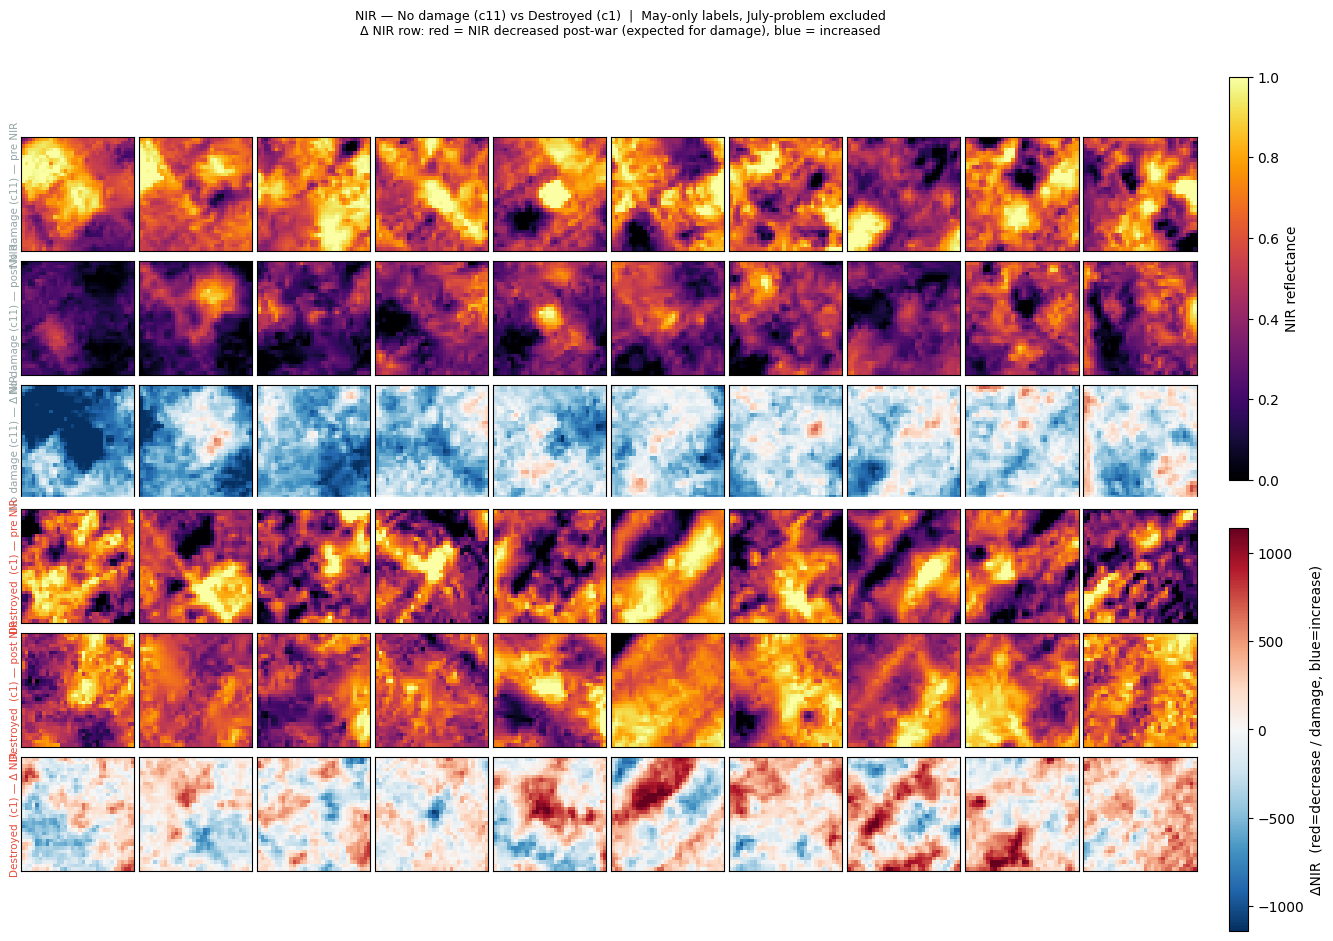

In [ ]:
# ── pools: only May-confirmed, July-clean categories ─────────────────────────
pool_intact  = np.where(cat7 == 'c11')[0]   # class 11 — no visible damage in May
pool_damaged = np.where(cat7 == 'c1')[0]    # class 1  — destroyed in May

print(f'c11 (no damage)  : {len(pool_intact):,} patches')
print(f'c1  (destroyed)  : {len(pool_damaged):,} patches')
print('No July-problem patches included — both pools are May-only assessments.')

N_EXAMPLES = 10

def nir_triple(patch):
    pre      = patch[nir_pre_ch].astype(float)
    post     = patch[nir_post_ch].astype(float)
    both     = np.concatenate([pre.ravel(), post.ravel()])
    lo, hi   = np.percentile(both, [2, 98])
    scale    = max(hi - lo, 1e-6)
    pre_s    = np.clip((pre  - lo) / scale, 0, 1)
    post_s   = np.clip((post - lo) / scale, 0, 1)
    diff_img = post - pre
    delta    = diff_img.mean()               # scalar for sorting
    return pre_s, post_s, diff_img, delta

# sort each pool by NIR delta: intact → least change first
#                               damaged → most decrease first (most negative)
def sorted_sample(pool, n, ascending=True):
    chosen = rng.choice(pool, size=min(n * 4, len(pool)), replace=False)
    deltas = np.array([nir_triple(X[j])[3] for j in chosen])
    order  = np.argsort(deltas) if ascending else np.argsort(deltas)
    return chosen[order[:n]]

intact_idx  = sorted_sample(pool_intact,  N_EXAMPLES, ascending=True)   # smallest delta
damaged_idx = sorted_sample(pool_damaged, N_EXAMPLES, ascending=True)    # most negative delta first

# ── compute global diff range for symmetric colourmap ─────────────────────────
all_diff_imgs = [nir_triple(X[j])[2] for j in np.concatenate([intact_idx, damaged_idx])]
diff_lim = np.percentile(np.abs(np.concatenate([d.ravel() for d in all_diff_imgs])), 98)

# ── figure: 6 rows × N_EXAMPLES cols ─────────────────────────────────────────
row_labels = [
    'No damage (c11) — pre NIR',
    'No damage (c11) — post NIR',
    'No damage (c11) — Δ NIR',
    'Destroyed  (c1) — pre NIR',
    'Destroyed  (c1) — post NIR',
    'Destroyed  (c1) — Δ NIR',
]

fig, axes = plt.subplots(6, N_EXAMPLES,
                         figsize=(N_EXAMPLES * 1.6, 6 * 1.6))

for col, j in enumerate(intact_idx):
    pre, post, diff_img, _ = nir_triple(X[j])
    axes[0, col].imshow(pre,      cmap='inferno', vmin=0, vmax=1)
    axes[1, col].imshow(post,     cmap='inferno', vmin=0, vmax=1)
    axes[2, col].imshow(diff_img, cmap='RdBu_r',  vmin=-diff_lim, vmax=diff_lim)

for col, j in enumerate(damaged_idx):
    pre, post, diff_img, _ = nir_triple(X[j])
    axes[3, col].imshow(pre,      cmap='inferno', vmin=0, vmax=1)
    axes[4, col].imshow(post,     cmap='inferno', vmin=0, vmax=1)
    axes[5, col].imshow(diff_img, cmap='RdBu_r',  vmin=-diff_lim, vmax=diff_lim)

# dividing line between the two classes
for col in range(N_EXAMPLES):
    for row in range(6):
        axes[row, col].set_xticks([]); axes[row, col].set_yticks([])
        if row == 2:
            axes[row, col].spines['bottom'].set_linewidth(3)
            axes[row, col].spines['bottom'].set_color('white')

for row, label in enumerate(row_labels):
    color = '#95A5A6' if row < 3 else '#E74C3C'
    axes[row, 0].set_ylabel(label, fontsize=7.5, rotation=90,
                             labelpad=4, va='center', color=color)

# colourbars
fig.subplots_adjust(right=0.86, hspace=0.04, wspace=0.04)
cb1 = fig.add_axes([0.88, 0.52, 0.012, 0.42])
fig.colorbar(plt.cm.ScalarMappable(cmap='inferno',
             norm=plt.Normalize(0, 1)), cax=cb1, label='NIR reflectance')

cb2 = fig.add_axes([0.88, 0.05, 0.012, 0.42])
fig.colorbar(plt.cm.ScalarMappable(cmap='RdBu_r',
             norm=plt.Normalize(-diff_lim, diff_lim)),
             cax=cb2, label='ΔNIR  (red=decrease / damage, blue=increase)')

plt.suptitle(
    'NIR — No damage (c11) vs Destroyed (c1)  |  May-only labels, July-problem excluded\n'
    'Δ NIR row: red = NIR decreased post-war (expected for damage), blue = increased',
    y=1.01, fontsize=9)

plt.savefig(str(FIGURES_DIR / 'eda_nir_c11_vs_c1.png'), dpi=150, bbox_inches='tight')
plt.show()

# Wasserstein Test

Computing Wasserstein scores for 228,725 patches …


  0%|          | 0/228725 [00:00<?, ?it/s]

score range: 0.000 – 26.747  | median: 0.000

Test-set evaluation:


,PR AUC,ROC AUC,F1 (best),precision,recall,threshold
Wasserstein,0.3738,0.4544,0.5691,0.3978,1.0000,0.000
PWTT,0.6306,0.7250,0.6234,0.5329,0.7509,2.627


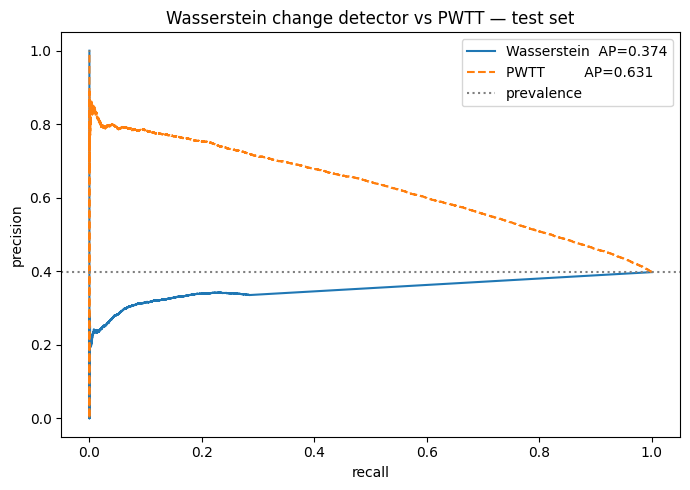

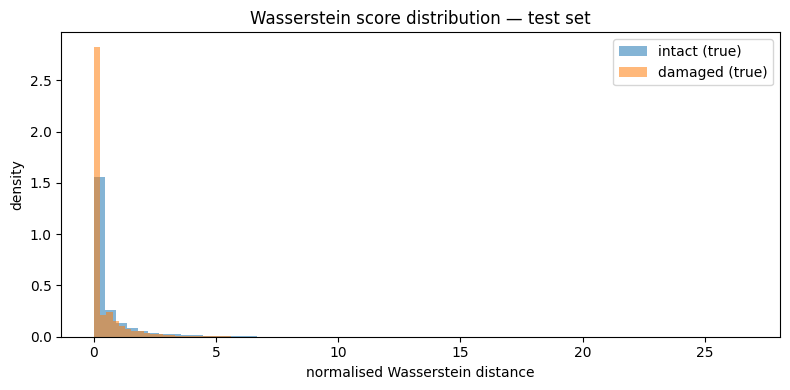

In [ ]:
from scipy.stats import wasserstein_distance
from sklearn.metrics import (average_precision_score, roc_auc_score,
                             precision_recall_curve, f1_score)
import numpy as np, pandas as pd
from tqdm.auto import tqdm

# ── channel indices ────────────────────────────────────────────────────────────
channel_names = list(z['channel_names'])
FP_IDX  = channel_names.index('fp_target')
PRE_IDX = [channel_names.index(f'ps_pre_{b}')  for b in BANDS]
POST_IDX= [channel_names.index(f'ps_post_{b}') for b in BANDS]

def wasserstein_score_nir(patch, min_pixels=5):
    mask = patch[FP_IDX] > 0.5
    if mask.sum() < min_pixels:
        mask = np.ones_like(mask, dtype=bool)

    from scipy.ndimage import distance_transform_edt
    soft = distance_transform_edt(mask).astype(float)
    soft /= soft.max() + 1e-6
    w = soft[mask].clip(min=1e-6)

    pi  = PRE_IDX[BANDS.index('NIR')]
    qi  = POST_IDX[BANDS.index('NIR')]
    pre  = patch[pi][mask].astype(float)
    post = patch[qi][mask].astype(float)
    pre_std = pre.std() + 1e-6

    wd_score = wasserstein_distance(pre, post, u_weights=w, v_weights=w) / pre_std

    # gate by direction: damage should decrease NIR, not increase it
    delta_nir = post.mean() - pre.mean()
    direction = max(0.0, -delta_nir / (abs(delta_nir) + 1e-6))

    return wd_score * direction


# ── compute on all patches (takes ~1-2 min for 228k) ─────────────────────────
print(f'Computing Wasserstein scores for {len(X):,} patches …')
w_scores = np.array([wasserstein_score_nir(X[i])
                     for i in tqdm(range(len(X)))])

print(f'score range: {w_scores.min():.3f} – {w_scores.max():.3f}  '
      f'| median: {np.median(w_scores):.3f}')


# ── evaluate on test split only ───────────────────────────────────────────────
test_idx = splits['test']
y_test   = y_binary[test_idx]
w_test   = w_scores[test_idx]

# also pull PWTT scores from the parquet if available
pwtt_col = 'max_change' if 'max_change' in table.columns else None

results = {}

for name, scores in [('Wasserstein', w_test),
                     ('PWTT', table.iloc[test_idx][pwtt_col].values
                      if pwtt_col else None)]:
    if scores is None:
        continue
    pr_auc  = average_precision_score(y_test, scores)
    roc_auc = roc_auc_score(y_test, scores)
    prec, rec, thr = precision_recall_curve(y_test, scores)
    f1s = 2*prec*rec / np.maximum(prec+rec, 1e-9)
    best = np.argmax(f1s[:-1])
    results[name] = {
        'PR AUC':    round(pr_auc, 4),
        'ROC AUC':   round(roc_auc, 4),
        'F1 (best)': round(f1s[best], 4),
        'precision': round(prec[best], 4),
        'recall':    round(rec[best], 4),
        'threshold': round(float(thr[best]), 4),
    }

print('\nTest-set evaluation:')
display(pd.DataFrame(results).T)


# ── precision-recall curve ────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(7, 5))

prec_w, rec_w, _ = precision_recall_curve(y_test, w_test)
ax.plot(rec_w, prec_w, label=f'Wasserstein  AP={results["Wasserstein"]["PR AUC"]:.3f}')

if pwtt_col:
    pwtt_test = table.iloc[test_idx][pwtt_col].values
    prec_p, rec_p, _ = precision_recall_curve(y_test, pwtt_test)
    ax.plot(rec_p, prec_p, label=f'PWTT         AP={results["PWTT"]["PR AUC"]:.3f}',
            linestyle='--')

ax.axhline(y_test.mean(), color='0.5', linestyle=':', label='prevalence')
ax.set(xlabel='recall', ylabel='precision',
       title='Wasserstein change detector vs PWTT — test set')
ax.legend()
plt.tight_layout()
plt.savefig(str(FIGURES_DIR / 'wasserstein_pr_curve.png'),
            dpi=150, bbox_inches='tight')
plt.show()


# ── score distribution by true label ─────────────────────────────────────────
fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(w_test[y_test==0], bins=60, density=True, alpha=.55, label='intact (true)')
ax.hist(w_test[y_test==1], bins=60, density=True, alpha=.55, label='damaged (true)')
ax.set_xlabel('normalised Wasserstein distance')
ax.set_ylabel('density')
ax.set_title('Wasserstein score distribution — test set')
ax.legend()
plt.tight_layout()
plt.savefig(str(FIGURES_DIR / 'wasserstein_scores.png'),
            dpi=150, bbox_inches='tight')
plt.show()

### A2 — Post-minus-pre change distributions by band

Each panel is one spectral band. Distributions shift left (more negative) as
damage severity increases, with fully-destroyed and newly-destroyed buildings
showing the strongest signal. The "newly damaged by July" curves reveal how much
optical change is already visible in the June Planet scenes.

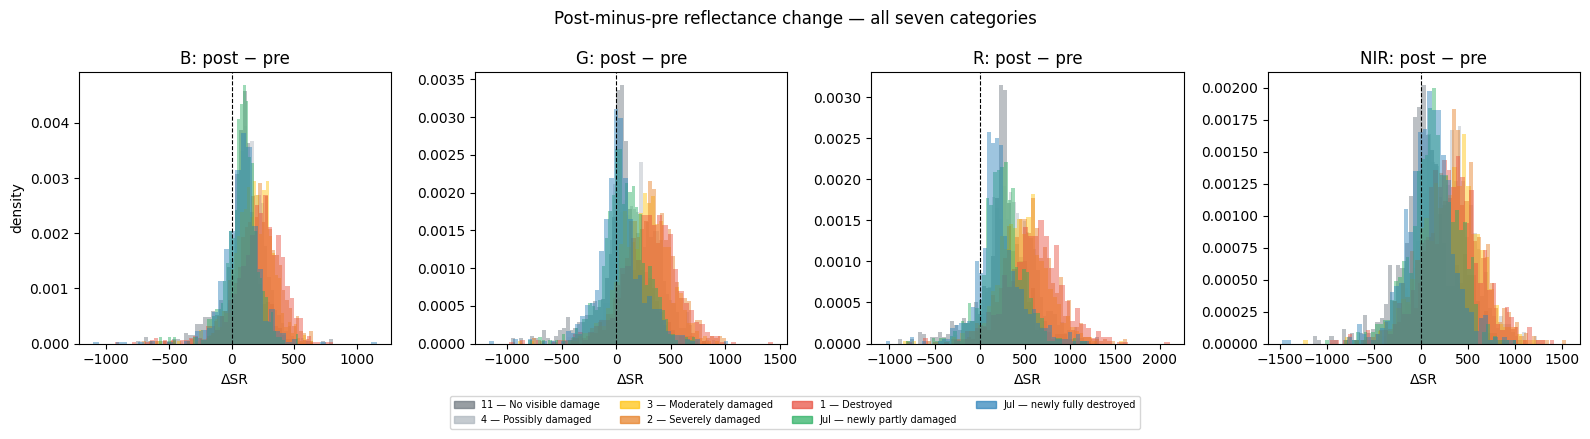

In [ ]:
fig, axes = plt.subplots(1, 4, figsize=(16, 4))
for j, (ax, band) in enumerate(zip(axes, BANDS)):
    for k in ORDER:
        vals = change[k][band]
        if not vals: continue
        ax.hist(vals, bins=50, density=True, alpha=.45,
                color=CAT_META[k]['color'], label=CAT_META[k]['label'])
    ax.axvline(0, color='k', lw=.8, ls='--')
    ax.set_title(f'{band}: post − pre'); ax.set_xlabel('ΔSR')
    ax.set_ylabel('density' if j==0 else '')
handles = [Patch(color=CAT_META[k]['color'], alpha=.7, label=CAT_META[k]['label'])
           for k in ORDER]
fig.legend(handles=handles, loc='lower center', ncol=4, fontsize=7,
           bbox_to_anchor=(.5, -.08))
plt.suptitle('Post-minus-pre reflectance change — all seven categories')
plt.tight_layout()
plt.savefig(str(PROJECT_DIR/'figures'/'eda_change_histograms.png'),
            dpi=150, bbox_inches='tight')
plt.show()

### A3 — NDVI change and summary severity gradient

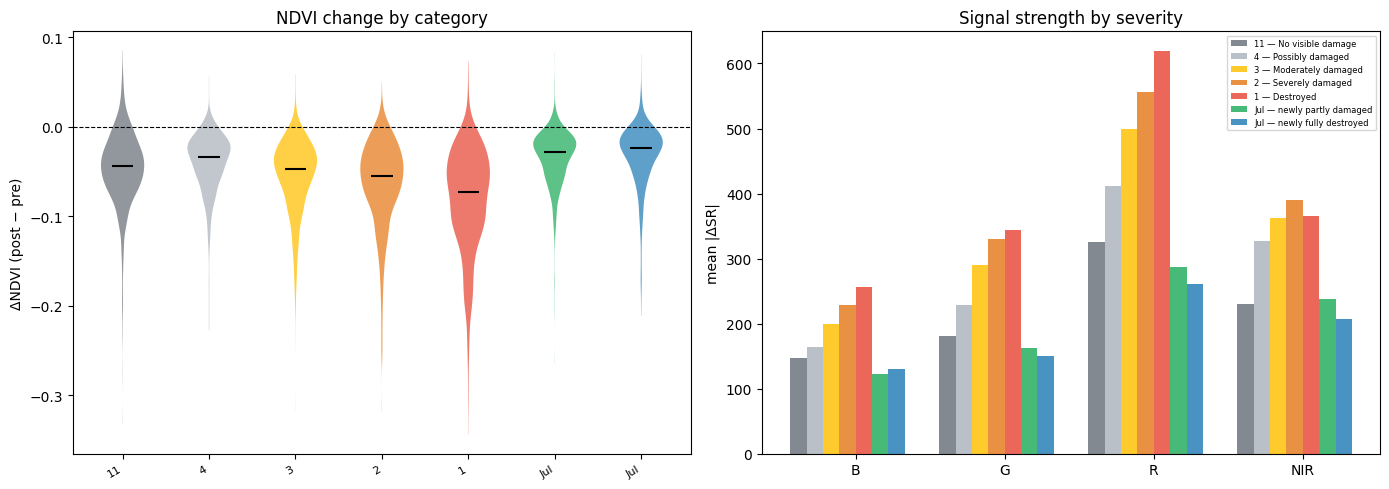

Median ΔNDVI per category:
  11 — No visible damage                   -0.0435
  4 — Possibly damaged                     -0.0336
  3 — Moderately damaged                   -0.0473
  2 — Severely damaged                     -0.0555
  1 — Destroyed                            -0.0727
  Jul — newly partly damaged               -0.0280
  Jul — newly fully destroyed              -0.0240


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# left: NDVI change violin
parts = [np.array(ndvi_delta[k]) for k in ORDER if ndvi_delta[k]]
labels_used = [k for k in ORDER if ndvi_delta[k]]
vp = axes[0].violinplot(parts, showmedians=True, showextrema=False)
for body, k in zip(vp['bodies'], labels_used):
    body.set_facecolor(CAT_META[k]['color']); body.set_alpha(.75)
vp['cmedians'].set_color('black'); vp['cmedians'].set_linewidth(1.5)
axes[0].axhline(0, color='k', lw=.8, ls='--')
axes[0].set_xticks(range(1, len(labels_used)+1))
axes[0].set_xticklabels([CAT_META[k]['label'].split('—')[0].strip()
                          for k in labels_used], rotation=30, ha='right', fontsize=8)
axes[0].set_ylabel('ΔNDVI (post − pre)'); axes[0].set_title('NDVI change by category')

# right: mean |change| per band as grouped bars (severity gradient)
band_means = {k: [np.abs(change[k][b]).mean() if change[k][b] else 0
                  for b in BANDS] for k in ORDER}
x = np.arange(4); width = 0.11
for i,k in enumerate(ORDER):
    axes[1].bar(x + i*width, band_means[k], width, color=CAT_META[k]['color'],
                alpha=.85, label=CAT_META[k]['label'])
axes[1].set_xticks(x + width*3.5); axes[1].set_xticklabels(BANDS)
axes[1].set_ylabel('mean |ΔSR|'); axes[1].set_title('Signal strength by severity')
axes[1].legend(fontsize=6, ncol=1)

plt.tight_layout()
plt.savefig(str(PROJECT_DIR/'figures'/'eda_ndvi_and_gradient.png'),
            dpi=150, bbox_inches='tight')
plt.show()

# print median NDVI change per category as a table
print('Median ΔNDVI per category:')
for k in ORDER:
    v = ndvi_delta[k]
    if v: print(f'  {CAT_META[k]["label"]:40s} {np.median(v):+.4f}')

## B · Spatial clustering and data-leakage risk

### B1 — Local damage rate via KNN

For every footprint, find its k=20 nearest geographic neighbours and compute what
fraction of them are labelled damaged. This produces a spatially smoothed damage
surface. A high local rate next to a building labelled intact is the clearest
single-point indicator of label noise (either a genuine UNOSAT miss, or a building
labelled in May before July destruction reached it).

In [ ]:
# UTM coordinates for distance computation
x_utm = table_utm.geometry.centroid.x.values
y_utm = table_utm.geometry.centroid.y.values
coords = np.column_stack([x_utm, y_utm])

K = 20
print(f'Building KNN tree for {len(coords):,} footprints (k={K}) …')
tree = cKDTree(coords)
dists, nbr_idx = tree.query(coords, k=K+1)   # k+1 because first result is self
nbr_idx = nbr_idx[:, 1:]                      # exclude self
local_rate = y_binary[nbr_idx].mean(axis=1)   # fraction of k neighbours that are damaged

# add to table for later use
table['local_rate'] = local_rate
table['x_utm'] = x_utm
table['y_utm'] = y_utm

print(f'Global prevalence          : {100*y_binary.mean():.1f}%')
print(f'Mean local rate (k={K})    : {100*local_rate.mean():.1f}%')
print(f'Corr(local_rate, label)    : {np.corrcoef(local_rate, y_binary)[0,1]:.3f}')

Building KNN tree for 228,725 footprints (k=20) …
Global prevalence          : 57.5%
Mean local rate (k=20)    : 58.2%
Corr(local_rate, label)    : 0.808


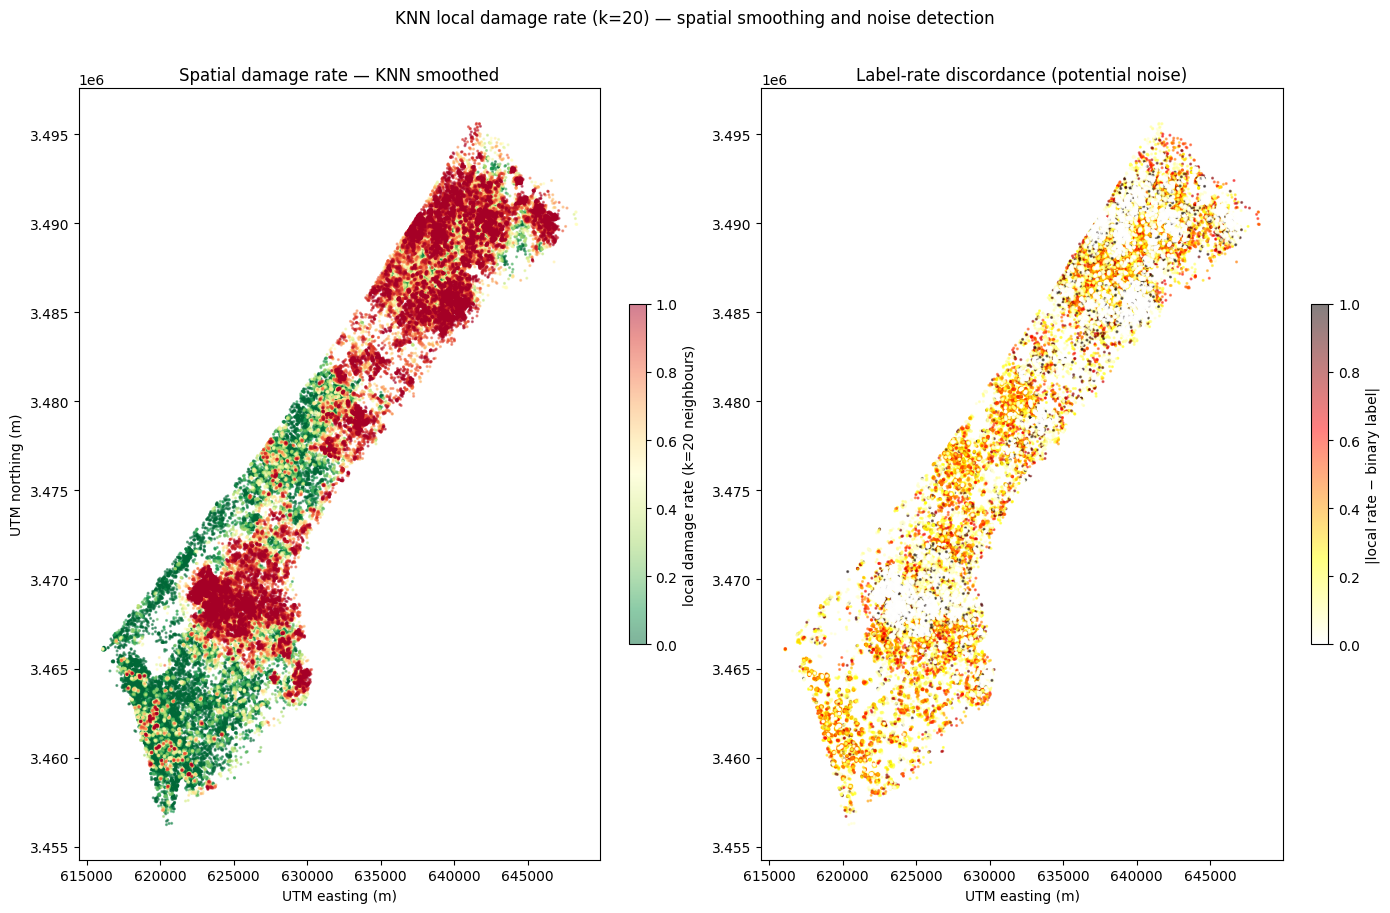

In [ ]:
# ── spatial map coloured by local damage rate ────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 9))

# sample for speed
samp = rng.choice(len(table), min(60_000, len(table)), replace=False)
samp = samp[np.argsort(local_rate[samp])]   # draw low-rate first so high-rate visible

sc = axes[0].scatter(table['x_utm'].iloc[samp], table['y_utm'].iloc[samp],
                     c=local_rate[samp], cmap='RdYlGn_r',
                     s=1.5, alpha=.5, vmin=0, vmax=1)
plt.colorbar(sc, ax=axes[0], fraction=.03, label='local damage rate (k=20 neighbours)')
axes[0].set_title('Spatial damage rate — KNN smoothed')
axes[0].set_xlabel('UTM easting (m)'); axes[0].set_ylabel('UTM northing (m)')

# binary label vs local rate: show potential noise cases
disc = np.abs(local_rate - y_binary)      # 0 if agree, 1 if completely disagree
axes[1].scatter(table['x_utm'].iloc[samp], table['y_utm'].iloc[samp],
                c=disc[samp], cmap='hot_r', s=1.5, alpha=.5, vmin=0, vmax=1)
plt.colorbar(axes[1].collections[0], ax=axes[1], fraction=.03,
             label='|local rate − binary label|')
axes[1].set_title('Label-rate discordance (potential noise)')
axes[1].set_xlabel('UTM easting (m)')

plt.suptitle('KNN local damage rate (k=20) — spatial smoothing and noise detection',
             y=1.01)
plt.tight_layout()
plt.savefig(str(PROJECT_DIR/'figures'/'eda_knn_local_rate.png'),
            dpi=150, bbox_inches='tight')
plt.show()

### B2 — Data-leakage illustration: random vs latitude-quantile split

For any geographic dataset, a random split almost guarantees that many test
buildings have a training neighbour within the spillover radius (28 m in Ballinger).
The latitude-quantile split avoids this by placing each latitude band entirely in
one role. The plot below makes this concrete.

Geographic split  — test pts within 28m of a train pt: 0.0%
Random split      — test pts within 28m of a train pt: 77.0%


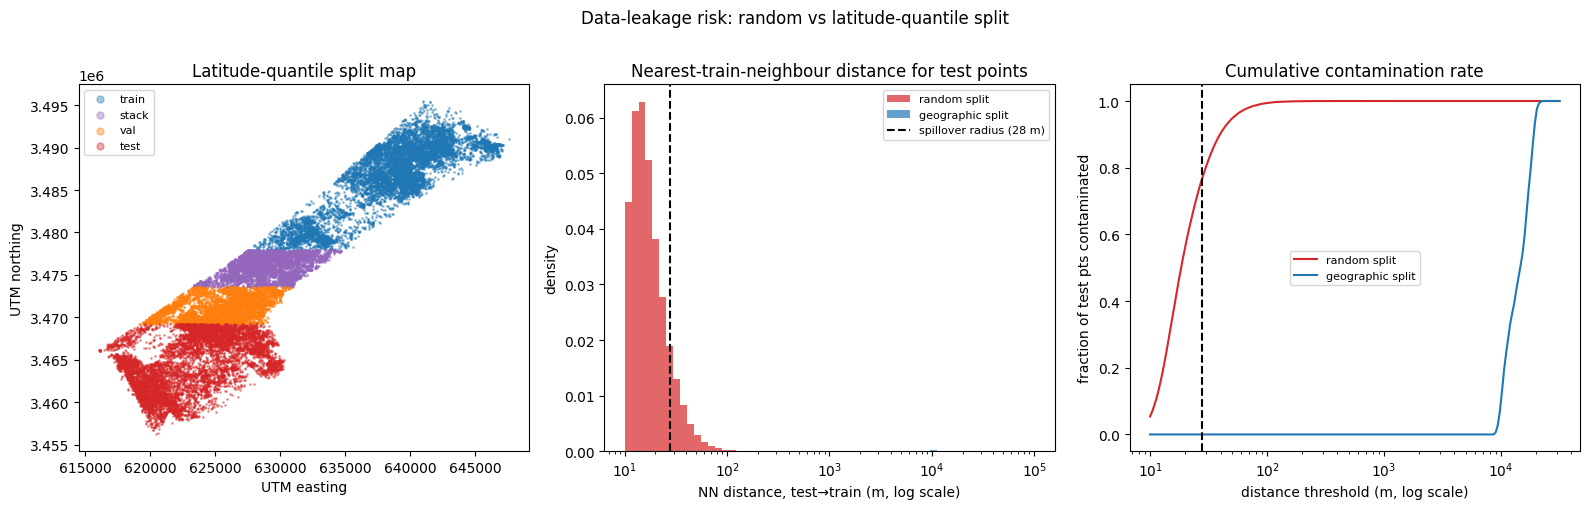

In [ ]:
# ── reconstruct the split used in training ───────────────────────────────────
# latitude-quantile bands: train=[0.55,1], stack=[0.44,0.55], val=[0.33,0.44], test=[0,0.33]
lat = table['y_utm'].values if 'y_utm' in table.columns else y_utm
lat_pct = (lat - lat.min()) / (lat.max() - lat.min())

splits = {
    'train': np.where((lat_pct>=0.55))[0],
    'stack': np.where((lat_pct>=0.44)&(lat_pct<0.55))[0],
    'val':   np.where((lat_pct>=0.33)&(lat_pct<0.44))[0],
    'test':  np.where(lat_pct<0.33)[0],
}
SPLIT_COLORS = {'train':'tab:blue','stack':'tab:purple','val':'tab:orange','test':'tab:red'}

# ── compute nearest-train-neighbour distance for every test point ─────────────
train_coords = coords[splits['train']]
test_coords  = coords[splits['test']]
tree_train   = cKDTree(train_coords)

nn_geo_dist, _  = tree_train.query(test_coords, k=1)   # geographic split
# random split baseline: randomly assign training roles
rng_base = np.random.default_rng(42)
all_idx = np.arange(len(coords))
rng_base.shuffle(all_idx)
n_train = len(splits['train'])
train_rand = all_idx[:n_train]; test_rand = all_idx[n_train+len(splits['stack'])+len(splits['val']):]
tree_rand  = cKDTree(coords[train_rand])
nn_rand_dist, _ = tree_rand.query(coords[test_rand], k=1)

SPILLOVER = 28     # Ballinger median false-positive distance (m)
print(f'Geographic split  — test pts within {SPILLOVER}m of a train pt: '
      f'{100*(nn_geo_dist<SPILLOVER).mean():.1f}%')
print(f'Random split      — test pts within {SPILLOVER}m of a train pt: '
      f'{100*(nn_rand_dist<SPILLOVER).mean():.1f}%')

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# split map
for role, color in SPLIT_COLORS.items():
    idx = splits[role]
    s = rng.choice(idx, min(10000,len(idx)), replace=False)
    axes[0].scatter(coords[s,0], coords[s,1], c=color, s=1, alpha=.4, label=role)
axes[0].legend(markerscale=5, fontsize=8)
axes[0].set_title('Latitude-quantile split map')
axes[0].set_xlabel('UTM easting'); axes[0].set_ylabel('UTM northing')

# NN distance distributions
bins = np.logspace(1, 5, 60)
axes[1].hist(nn_rand_dist, bins=bins, density=True, alpha=.7,
             label='random split', color='tab:red')
axes[1].hist(nn_geo_dist,  bins=bins, density=True, alpha=.7,
             label='geographic split', color='tab:blue')
axes[1].axvline(SPILLOVER, color='k', ls='--', lw=1.5,
                label=f'spillover radius ({SPILLOVER} m)')
axes[1].set_xscale('log')
axes[1].set_xlabel('NN distance, test→train (m, log scale)')
axes[1].set_ylabel('density')
axes[1].set_title('Nearest-train-neighbour distance for test points')
axes[1].legend(fontsize=8)

# cumulative contamination rate vs distance threshold
thresholds = np.logspace(1, 4.5, 200)
axes[2].plot(thresholds, [(nn_rand_dist<t).mean() for t in thresholds],
             color='tab:red', label='random split')
axes[2].plot(thresholds, [(nn_geo_dist<t).mean() for t in thresholds],
             color='tab:blue', label='geographic split')
axes[2].axvline(SPILLOVER, color='k', ls='--', lw=1.5)
axes[2].set_xscale('log')
axes[2].set_xlabel('distance threshold (m, log scale)')
axes[2].set_ylabel('fraction of test pts contaminated')
axes[2].set_title('Cumulative contamination rate')
axes[2].legend(fontsize=8)

plt.suptitle('Data-leakage risk: random vs latitude-quantile split', y=1.01)
plt.tight_layout()
plt.savefig(str(PROJECT_DIR/'figures'/'eda_leakage.png'),
            dpi=150, bbox_inches='tight')
plt.show()

## C · Systematic split comparison

Label rule for all plots: **UNOSAT classes 1–3 = damaged, class 4 and 11 = intact**
(class 6 and unmatched treated as intact in the binary label).

In [ ]:
# ── structural summary table ──────────────────────────────────────────────────
rows = []
for role in ('train','stack','val','test'):
    idx = splits[role]
    y_r = y_binary[idx]
    lat_r = lat[idx]
    area_r = table.iloc[idx]['area'].values if 'area' in table.columns else np.full(len(idx),np.nan)
    local_r = local_rate[idx]

    # category breakdown
    cat_r = cat7[idx]
    cat_counts = {k: (cat_r==k).sum() for k in ORDER}

    rows.append({
        'role':             role,
        'n':                len(idx),
        'prevalence (%)':   round(100*y_r.mean(),1),
        'lat range (km)':   f'{(lat_r.max()-lat_r.min())/1000:.1f}',
        'median area (m²)': round(np.nanmedian(area_r),0),
        'mean local rate':  round(local_r.mean(),3),
        **{f'n_{k}': cat_counts[k] for k in ORDER},
    })
summary = pd.DataFrame(rows).set_index('role')
print('Split summary:')
display(summary[['n','prevalence (%)','lat range (km)','median area (m²)','mean local rate']])

Split summary:


,n,prevalence (%),lat range (km),median area (m²),mean local rate
role,,,,,
train,111415,72.5,17.8,160.0,0.731
stack,19512,33.0,4.3,149.0,0.339
val,20830,65.9,4.3,142.0,0.667
test,76968,39.8,13.0,148.0,0.405


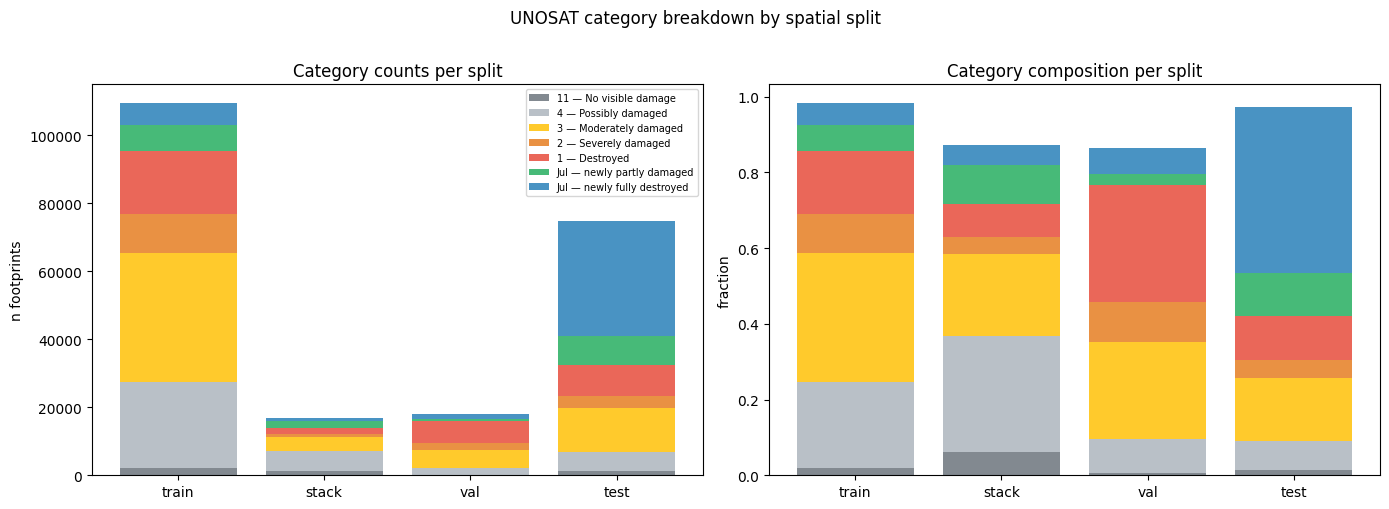

In [ ]:
# ── stacked bar: UNOSAT category composition per split ───────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

roles = ['train','stack','val','test']
x = np.arange(len(roles))

# absolute counts stacked
bottom = np.zeros(len(roles))
for k in ORDER:
    vals = np.array([summary.loc[r, f'n_{k}'] for r in roles])
    axes[0].bar(x, vals, bottom=bottom, color=CAT_META[k]['color'],
                alpha=.85, label=CAT_META[k]['label'])
    bottom += vals
axes[0].set_xticks(x); axes[0].set_xticklabels(roles)
axes[0].set_ylabel('n footprints'); axes[0].set_title('Category counts per split')
axes[0].legend(fontsize=7, loc='upper right')

# normalised stacked (fraction)
total = np.array([summary.loc[r,'n'] for r in roles], float)
bottom = np.zeros(len(roles))
for k in ORDER:
    vals = np.array([summary.loc[r, f'n_{k}'] for r in roles]) / total
    axes[1].bar(x, vals, bottom=bottom, color=CAT_META[k]['color'], alpha=.85)
    bottom += vals
axes[1].set_xticks(x); axes[1].set_xticklabels(roles)
axes[1].set_ylabel('fraction'); axes[1].set_title('Category composition per split')

plt.suptitle('UNOSAT category breakdown by spatial split', y=1.01)
plt.tight_layout()
plt.savefig(str(PROJECT_DIR/'figures'/'eda_split_categories.png'),
            dpi=150, bbox_inches='tight')
plt.show()

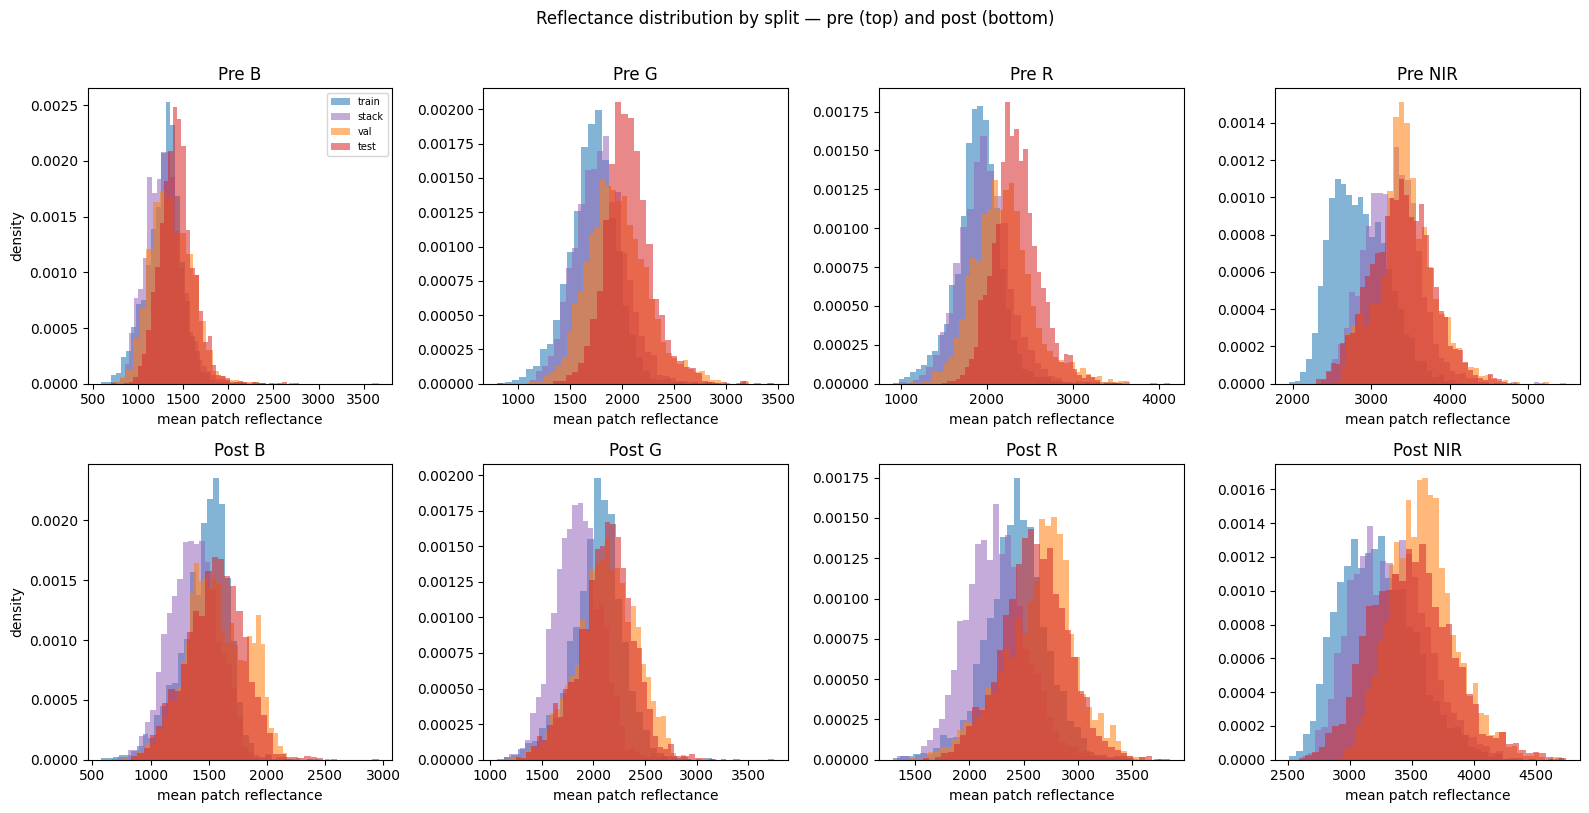

In [ ]:
# ── spectral statistics per split ────────────────────────────────────────────
fig, axes = plt.subplots(2, 4, figsize=(16, 8), sharey=False)
for j, band in enumerate(BANDS):
    for period, row in [('pre',0),('post',1)]:
        ax = axes[row, j]
        for role, color in SPLIT_COLORS.items():
            idx = splits[role]
            samp_s = rng.choice(idx, min(3000,len(idx)), replace=False)
            ch = j if period=='pre' else j+4
            vals = X[samp_s, ch].mean(axis=(1,2))
            ax.hist(vals, bins=40, density=True, alpha=.55,
                    color=color, label=role)
        ax.set_title(f'{"Pre" if period=="pre" else "Post"} {band}')
        ax.set_xlabel('mean patch reflectance')
        if j==0: ax.set_ylabel('density')
        if j==0 and row==0: ax.legend(fontsize=7)
plt.suptitle('Reflectance distribution by split — pre (top) and post (bottom)',
             y=1.01)
plt.tight_layout()
plt.savefig(str(PROJECT_DIR/'figures'/'eda_split_spectral.png'),
            dpi=150, bbox_inches='tight')
plt.show()

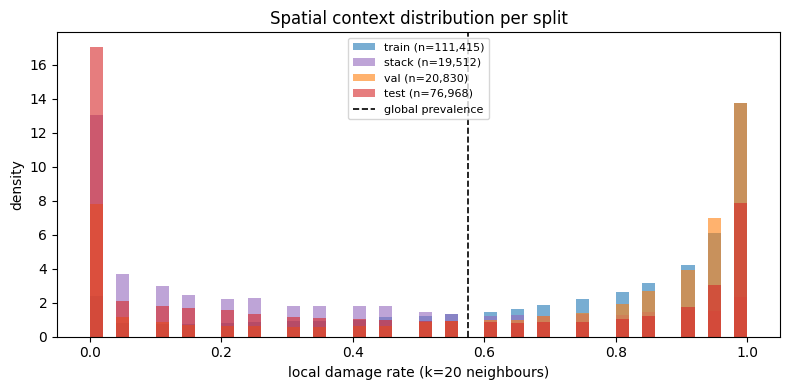

Role        prev%   mean local rate   fraction with local>0.8
train        72.5             0.731                     0.545
stack        33.0             0.339                     0.137
val          65.9             0.667                     0.548
test         39.8             0.405                     0.278


In [ ]:
# ── local damage rate distribution per split ─────────────────────────────────
fig, ax = plt.subplots(figsize=(8, 4))
for role, color in SPLIT_COLORS.items():
    idx = splits[role]
    ax.hist(local_rate[idx], bins=50, density=True, alpha=.6,
            color=color, label=f'{role} (n={len(idx):,})')
ax.axvline(y_binary.mean(), color='k', ls='--', lw=1.2, label='global prevalence')
ax.set_xlabel(f'local damage rate (k={K} neighbours)')
ax.set_ylabel('density')
ax.set_title('Spatial context distribution per split')
ax.legend(fontsize=8)
plt.tight_layout()
plt.savefig(str(PROJECT_DIR/'figures'/'eda_split_local_rate.png'),
            dpi=150, bbox_inches='tight')
plt.show()

# print summary stats
print(f'{"Role":8s}  {"prev%":>7s}  {"mean local rate":>16s}  '
      f'{"fraction with local>0.8":>24s}')
for role in roles:
    idx = splits[role]
    print(f'{role:8s}  {100*y_binary[idx].mean():7.1f}  '
          f'{local_rate[idx].mean():16.3f}  '
          f'{(local_rate[idx]>0.8).mean():24.3f}')

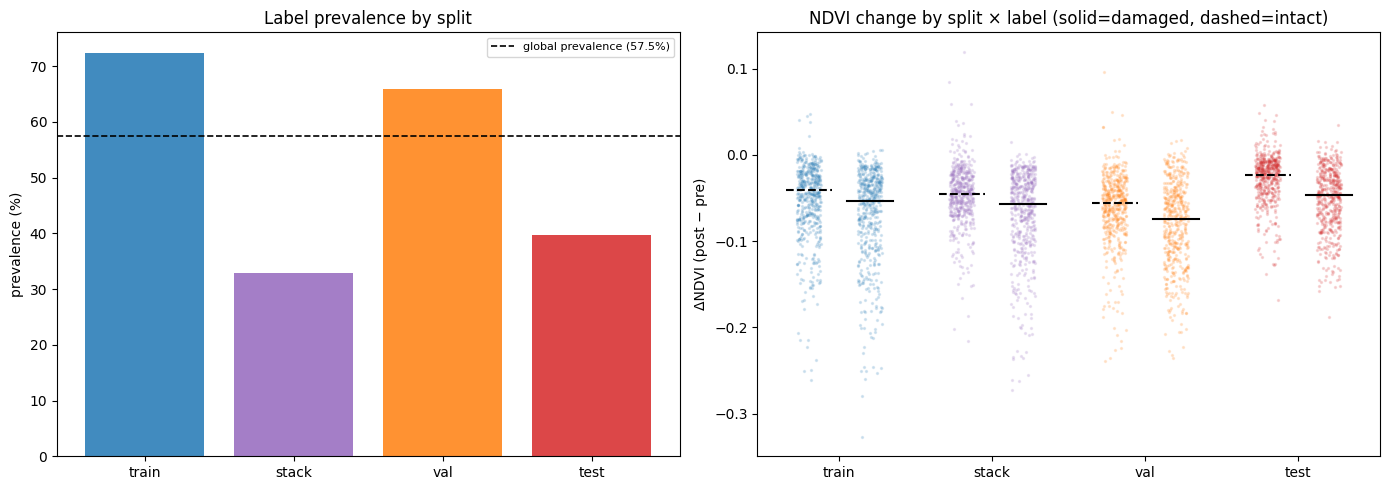

In [ ]:
# ── prevalence and NDVI-change by split and binary label ─────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# prevalence: compare split native prevalence vs. what would be expected from
# a random split at the global rate — shows systematic geographic imbalance
global_prev = y_binary.mean()
split_prev  = {r: y_binary[splits[r]].mean() for r in roles}
axes[0].bar(range(len(roles)),
            [split_prev[r]*100 for r in roles],
            color=[SPLIT_COLORS[r] for r in roles], alpha=.85)
axes[0].axhline(global_prev*100, color='k', ls='--', lw=1.2,
                label=f'global prevalence ({100*global_prev:.1f}%)')
axes[0].set_xticks(range(len(roles))); axes[0].set_xticklabels(roles)
axes[0].set_ylabel('prevalence (%)'); axes[0].set_title('Label prevalence by split')
axes[0].legend(fontsize=8)

# NDVI change: intact vs damaged by split
# recompute NDVI delta per footprint
pre_ndvi_fp  = np.where(X[:,3]+X[:,2]>0,
                        (X[:,3]-X[:,2])/(X[:,3]+X[:,2]+1e-6), 0)
post_ndvi_fp = np.where(X[:,7]+X[:,6]>0,
                        (X[:,7]-X[:,6])/(X[:,7]+X[:,6]+1e-6), 0)
ndvi_d = (post_ndvi_fp - pre_ndvi_fp).mean(axis=(1,2))

for j, role in enumerate(roles):
    idx = splits[role]
    for cls, ls, lbl in [(0,'--','intact'),(1,'-','damaged')]:
        vals = ndvi_d[idx[y_binary[idx]==cls]]
        axes[1].plot([], [], color=SPLIT_COLORS[role], ls=ls,
                     label=f'{role} {lbl}' if j<2 else '_')
        # violin per split×class — use scatter jitter
        xpos = j + (0.2 if cls else -0.2)
        axes[1].scatter(np.full(min(500,len(vals)), xpos) +
                        rng.uniform(-0.08,0.08,min(500,len(vals))),
                        rng.choice(vals, min(500,len(vals)), replace=False),
                        alpha=.15, s=2, color=SPLIT_COLORS[role])
        axes[1].plot([xpos-0.15, xpos+0.15], [np.median(vals)]*2,
                     color='black', lw=1.5, ls=ls)

axes[1].set_xticks(range(len(roles))); axes[1].set_xticklabels(roles)
axes[1].set_ylabel('ΔNDVI (post − pre)')
axes[1].set_title('NDVI change by split × label (solid=damaged, dashed=intact)')

plt.tight_layout()
plt.savefig(str(PROJECT_DIR/'figures'/'eda_split_prevalence_ndvi.png'),
            dpi=150, bbox_inches='tight')
plt.show()

In [ ]:
from IPython.display import Audio
import numpy as np

def beep(freq=440, duration=0.4, sr=22050):
    t = np.linspace(0, duration, int(sr*duration), False)
    wave = 0.3 * np.sin(2 * np.pi * freq * t)
    # fade in/out to avoid clicks
    fade = int(sr * 0.02)
    wave[:fade] *= np.linspace(0, 1, fade)
    wave[-fade:] *= np.linspace(1, 0, fade)
    return wave

sr = 22050
# Nokia ringtone — E5 D5 F#4 G#4 / E5 D5 F#4 G#4 / E5 D5 E5
notes = {
    'G#4': 415.30, 'F#4': 369.99,
    'D5':  587.33, 'E5':  659.25,
    'B4':  493.88, 'C#5': 554.37,
}
sequence = [
    ('E5',0.25),('D5',0.25),('F#4',0.5),('G#4',0.5),
    ('E5',0.25),('D5',0.25),('F#4',0.5),('G#4',0.5),
    ('E5',0.25),('D5',0.25),('E5',0.25),('C#5',0.25),('D5',0.75),
    ('B4',0.25),('C#5',0.25),('D5',0.5),
]

song = np.concatenate([
    np.concatenate([beep(notes[n], d, sr), np.zeros(int(sr*0.05))])
    for n, d in sequence
])

print('✓ All done')
Audio(song, rate=sr, autoplay=True)

✓ All done
